**Analysis of Alveolar Type II Cell Transcriptional States in Lethal COVID-19 Lung Biopsies**

by Ashley Ramsawhook, PhD.

This work is an independent analysis of the Alveolar Type II (AT2) cell transcriptional state in lethal COVID-19 lung biopsies taken from Melms *et al*, 2021 (https://doi.org/10.1038/s41586-021-03569-1). While this notebook reproduces and modifies the pre-processing steps of the raw data performed by the authors, the exploration, analysis, deductions and conclusion are independent and self-directed. The agentic Large Language Model (LLM), Claude Sonnet 5.0 (Anthropic) was utilised for code debugging, statistical methodology discussions and literature dataset navigation. All code and markdown were written by myself.



**The Dataset**

The Melms *et al*, 2021 dataset consisted of lung biopsies extracted from 7 healthy donors and 19 COVID patients harvested post-mortem and sequencing libraries were prepared from single nuclei suspensions. Only one biopsy was harvested per donor, making the terms “Sample” and “Donor” synonymous for this dataset. Ambient RNA and debris contamination had been excluded from raw counts by the authors using CELL BENDER prior to publication of the dataset.   

**External Resources for Annotation**

A curated list of human ribosomal genes was acquired from the Broad Institute's software repository: http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp?geneSetName=KEGG_RIBOSOME&fileType=txt

**Installing Necessary Libraries and Dependencies**

In [ ]:
%pip install scanpy

In [ ]:
%pip install scvi-tools

In [ ]:
%pip install scikit-misc

In [ ]:
! pip install leidenalg

In [ ]:
! pip install gseapy

In [ ]:
! pip install celltypist --break-system-packages

In [ ]:
! pip install pydeseq2 

**Import the Necessary Libraries**

In [ ]:
import pandas as pd
import numpy as np
import os
import scipy
import glob
from pathlib import Path
import seaborn as sns
from scipy.sparse import csr_matrix, issparse
import scanpy as sc
import scvi
import matplotlib.pyplot as plt
import gseapy as gp
from scipy import stats
import celltypist
from celltypist import models
import requests
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

**Setting the File Paths for Reading-in and Saving Data** 

In [2]:
from pathlib import Path

In [3]:
#Setting the input data path which contains the raw counts files
DATA_DIR = Path("E:/New Python/scRNA-seq/Tutorial/Covid scRNA-seq lung atlas/unzipped raw counts")
files = list(DATA_DIR.glob("*.csv"))

In [4]:
#Setting the output path for saving models and processed files
OUTPUT_DIR = "E:/New Python/scRNA-seq/Tutorial/Covid scRNA-seq lung atlas/processed"

**Import the Curated Geneset for Ribosomal Gene Annotation**



In [5]:
#Import the Broad Institute's Ribosomal Geneset
RIBO_LIST = Path("E:/New Python/scRNA-seq/Tutorial/Covid scRNA-seq lung atlas/KEGG_RIBOSOME.v2026.1.Hs.txt" )
ribo_genes = pd.read_table(RIBO_LIST, skiprows=2, header= None)

**Clustering**

The latent representation data was used to generate UMAP clusters based on normalised read counts

In [87]:
#Calculate the neighbours using X_scVI
sc.pp.neighbors(adata_combined, use_rep= "X_scVI")

The Leiden algorithm was used for UMAP clustering and cluster label assignment.  

In [ ]:
#Install the leiden algorithm
! pip install leidenalg

In [89]:
#Visualise the clusters
sc.tl.umap(adata_combined)
sc.tl.leiden(adata_combined, resolution= 1)

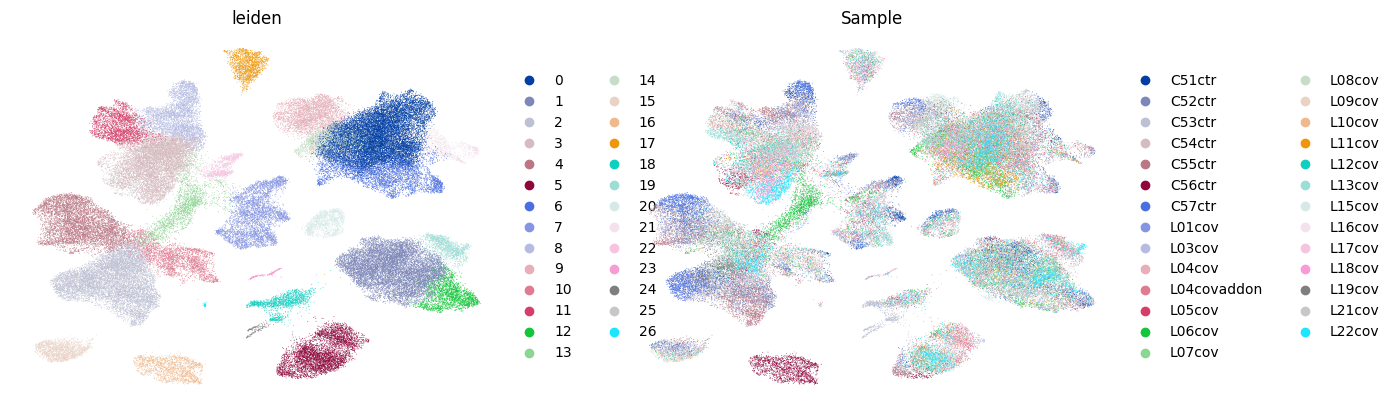

In [90]:
#Plot the Clusters with the clusters labelled and then the sample labelled to demonstrate the effect of integration
sc.pl.umap(adata_combined, color=["leiden", "Sample"], frameon= False)

**Save the Cluster Map**

In [91]:
#Save the integrated anndata object
adata_combined.write_h5ad("integrated_anndata.h5ad")

**Find Markers / Label Cell Types**

Cell types were interrogated via exploration of canocical markers corroborated by multiple sources (Human Cell Atlas, CellxGene and PanglaoDB). Cell type label assignment of clusters was cross-referenced against CellTypist output to verify labelling accuracy.  

In [ ]:
#Obtain ranked of marker genes based on Leiden
sc.tl.rank_genes_groups(adata_combined, "leiden")

In [ ]:
#Plot the markers
sc.pl.rank_genes_groups(adata_combined, n_genes=20, sharey=False)

A dataframe of the ranked genes was generated to include genes with adjusted p-values less than 0.05 and with a log fold change greater than 0.5.

In [ ]:
markers = sc.get.rank_genes_groups_df(adata_combined, None)
markers = markers[(markers.pvals_adj < 0.05) & (markers.logfoldchanges > .5)]
markers

In [ ]:
#Calculate the differential marker expression between clusters identified based on leiden
markers_scvi = model_integration.differential_expression(groupby= "leiden")
markers_scvi

In [ ]:
#Check scVI features
print(markers_scvi.columns.tolist())

No log2foldchange metric exists for this version of SCVI-tools. Therefore feature engineering was performed to create log2fold change from scale1 and scale2 features.

In [97]:
#Feature engineering to create lfc_mean
markers_scvi["lfc_mean"] = np.log2(
    (markers_scvi["scale2"] + 1e-9) / (markers_scvi["scale1"] + 1e-9)
)

In [ ]:
#Screen for the most differentially expressed genes as markers
markers_scvi = markers_scvi[
    (markers_scvi["bayes_factor"].abs() > 3) &
    (markers_scvi["lfc_mean"] > 0.5)
]
markers_scvi

**Map Leiden Labels to Clusters**

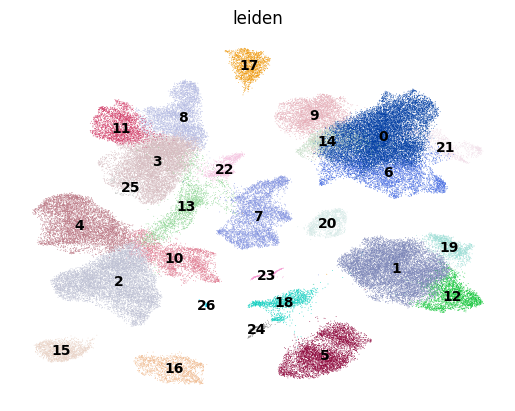

In [99]:
sc.pl.umap(adata_combined, color= ["leiden"], frameon= False, legend_loc= "on data")

Cell type clusters were manually annotated via corss-referencing the Human Cell Atlas, CellxGene and PanglaoDB databases. Almost every scRNA-seq dataset from biopsies will have blood cells in it unless deliberately filtered out. Therefore blood cell markers were used as a reference point for cell type mapping to the clusters.

In [ ]:
#Check to see if erythroblast marker genes are in the 3000 HVG slice
for gene in ["CGA", "GYPA", "TFRC", "BPGM", "KIT", "IGBP1", "PIEZO1", "KMT5A", "TAL1", "GATA1", "LMO2", "ENG", "CFP",
              "ITGB1", "USE1", "GRSF1", "LRP8", "LMNB1", "TFR2", "EPOR", "CD44", "WRN", "CDH1", "ETS1"]:
    print(gene, gene in hvg_genes) 

In [6]:
#Using mapping the cell types from CellxGene Lung Atlas
cell_type_mapping = {
    "0":"Myeloid Dendritic Cells / Elicited Macrophages",
"1":"CD4 Alpha-Beta T Cells",
"2":"Alveolar Type II Cells",
"3":"Haematopoietic Stem Cells",
"4":"Alveolar Type I Cells",
"5":"Dendritic Cells / Plasma Cells",
"6":"Monocytes / Elicited Macrophages",
"7":"Endothelial Cells",
"8":"Lung Pericyte",
"9":"Lung Macrophages",
"10":"Ionocytes /Basal Cells",
"11":"Stromal Cells",
"12":"CD8 Alpha-Beta Cells / Myeloid Dendritic Cells / Natural Killer Cells",
"13":"Haematopoietic Stem Cells",
"14":"Lung Macrophages",
"15":"Fibroblasts",
"16":"Club Cells / Ionocyte",
"17":"Endothelial Cells / Lymph Endothelial Cells",
"18":"Dendritic Cells / Natural Killer Cells",
"19":"CD8 Alpha-Beta Cells / Myeloid Dendritic Cells",
"20":"Mast Cells",
"21":"Dendritic Cells" ,
"22":"Lung Pericyte",
"23": "Myofibroblast",
"24": "Natural Killer Cells",
"25": "Multi-ciliated Epithelial Cells / Stromal Cells",
"26": "Pulmonary Endocrine Cells",
}

**Alveolar Macrophage**

In [ ]:
#Check to see if alveolar macrophage marker genes are in the 3000 HVG slice
for gene in ["CD163", "CD53", "CDK1", "CORO1A", "CYP27A1", "FABP4", "MARCO", "MRC1", "PPARG", "PTPRC", "SIGLEC1"]:
    print(gene, gene in hvg_genes) 

In [ ]:
#Visualising the marker expression by cluster
alveolar_macrophage_markers_genes = ["CD163", "CD53", "CDK1", "CORO1A", "CYP27A1", "FABP4", "MARCO", "MRC1", "PPARG", "PTPRC", "SIGLEC1"]

alveolar_mac_marker_expr = model_integration.get_normalized_expression(adata_combined, gene_list= alveolar_macrophage_markers_genes, library_size= 1e4)

for gene in alveolar_macrophage_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = alveolar_mac_marker_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in alveolar_macrophage_markers_genes], frameon= False )

In [ ]:
#Filter markers for unknown genes from cluster numbers
markers_scvi[markers_scvi.group1 == "0"]

**B Cell**

In [ ]:
#Check to see if B Cell marker genes are in the 3000 HVG slice
for gene in ["ANLN", "BANK1", "CD19", "CD22", "CD44", "CD53", "CD79A", "CDCA2", "CLSPN", "CORO1A", "E2F8", "FAM111B",
             "GTSE1", "HLA-DRA", "JCHAIN", "KIF4A", "MKI67", "MS4A1", "MYBL1", "NUF2", "NUGGC", "PAX5", "PTPRC", "SDC1",
               "TNFRSF13B"]:
    print(gene, gene in hvg_genes) 

In [ ]:
#Visualising the marker expression by cluster
b_cell_markers_genes = ["ANLN", "BANK1", "CD19", "CD22", "CD44", "CD53", "CD79A", "CDCA2", "CLSPN", "CORO1A", "E2F8", "FAM111B",
             "GTSE1", "HLA-DRA", "JCHAIN", "KIF4A", "MKI67", "MS4A1", "MYBL1", "NUF2", "NUGGC", "PAX5", "PTPRC", "SDC1",
               "TNFRSF13B"]

b_cell_marker_expr = model_integration.get_normalized_expression(adata_combined, gene_list= b_cell_markers_genes, library_size= 1e4)

for gene in b_cell_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = b_cell_marker_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in b_cell_markers_genes], frameon= False )

In [ ]:
#Filter markers for unknown genes from cluster numbers
markers_scvi[markers_scvi.group1 == "1"]

In [ ]:
b_cell_list =(markers_scvi[markers_scvi.group1 == "1"].index).tolist()
b_cell_list

**Goblet Cells**

In [ ]:
for gene in ["BPIFB1", "TMC5", "SAMD12", "EFNA5", "BACE2", "INSR", "LINC00342", "MUC5B", "MUC4", "GMDS", "MLPH", 
             "LINC00511", "CAPN8", "LINC01876", "PDE4D", "ANKRD36C", "CP", "CEACAM5", "SCGB1A1", "AGAP1", "CCSER1",
              "LMO7", "ARHGAP32", "PTPRN2", "ARHGAP26", "AHR", "NAALADL2", "CATSPERB", "PIGR", "DLEU1", "PSD3", "PATJ",
              "TMEM45A", "NEBL", "SPIDR", "MYH14", "TOX3", "MUC16", "TRAPPC9", "MECOM"]:
    print(gene, gene in hvg_genes) 

In [ ]:
#Visualising the marker expression by cluster
goblet_markers_genes = ["ANLN", "BANK1", "CD19", "CD22", "CD44", "CD53", "CD79A", "CDCA2", "CLSPN", "CORO1A", "E2F8", "FAM111B",
             "GTSE1", "HLA-DRA", "JCHAIN", "KIF4A", "MKI67", "MS4A1", "MYBL1", "NUF2", "NUGGC", "PAX5", "PTPRC", "SDC1",
               "TNFRSF13B"]

goblet_marker_expr = model_integration.get_normalized_expression(adata_combined, gene_list= goblet_markers_genes, library_size= 1e4)

for gene in goblet_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = goblet_marker_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in goblet_markers_genes], frameon= False )

In [ ]:
#Filter markers for unknown genes from cluster numbers
markers_scvi[markers_scvi.group1 == "5"]

In [ ]:
markers_scvi[markers_scvi.group1 == "5"].index.tolist()

**Bronchus Fibroblasts**

In [ ]:
for gene in ["LUM", "COL1A2", "DCN", "COL3A1", "COL6A3", "BGN", "C1S", "C1R", "COL6A2", "RARRES2", "COL6A1", "SPARC",
             "FN1", "PCOLCE", "AEBP1", "AEBP1", "NBL1", "FBLN1", "TIMP1", "COL5A2", "CTHRC1", "POSTN", "CTSK", "COL5A1",
             "NNMT", "CCDC80", "SERPING1", "LGALS1", "CALD1", "MFAP4", "THY1", "TAGLN", "SFRP2", "SELENOM", "VCAN"]:
    print(gene, gene in hvg_genes) 

In [ ]:
bronchus_fibroblast_markers_genes = ["LUM", "COL1A2", "DCN", "COL3A1", "COL6A3", "BGN", "C1S", "C1R", "COL6A2", "RARRES2", "COL6A1", "SPARC",
             "FN1", "PCOLCE", "AEBP1", "AEBP1", "NBL1", "FBLN1", "TIMP1", "COL5A2", "CTHRC1", "POSTN", "CTSK", "COL5A1",
             "NNMT", "CCDC80", "SERPING1", "LGALS1", "CALD1", "MFAP4", "THY1", "TAGLN", "SFRP2", "SELENOM", "VCAN"]

bronchus_fibroblast_marker_expr = model_integration.get_normalized_expression(adata_combined, gene_list= bronchus_fibroblast_markers_genes, library_size= 1e4)

for gene in bronchus_fibroblast_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = bronchus_fibroblast_marker_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in bronchus_fibroblast_markers_genes], frameon= False )

In [ ]:
markers_scvi[markers_scvi.group1 == "3"].index.tolist()

In [ ]:
markers_scvi[markers_scvi.group1 == "25"].index.tolist()

**Capillary Endothelial Cells**

In [ ]:
capillary_endothelial_markers_genes = ["CD93", "VWF", "EMCN", "EGFL7", "FLT1", "ID3", "KDR", "PECAM1", "PTPRB", "IGFBP7",
                                       "GNG11", "MCAM", "FLT4", "PLVAP", "ADGRF5", "ABCG2", "ACVRL1", "NRP2", "FHL2", "ARHGEF15",
                                       "DLL4", "CALCRL", "LYVE1", "ADGRL4", "CLDN5", "PDGFB", "ELK3", "CDH5", "RGS5", "ENG", "EPAS1", "ETS1",
                                       "CD34", "CLIC4", "ACKR1", "ID1", "ICAM1", "ITGB3", "SELE", "VCAM1", "PROCR", "TEK", "APLN", "NOS3", "THBD"]

capillary_endothelial_marker_expr = model_integration.get_normalized_expression(adata_combined, gene_list= capillary_endothelial_markers_genes, library_size= 1e4)

for gene in capillary_endothelial_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = capillary_endothelial_marker_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in capillary_endothelial_markers_genes], frameon= False )

In [ ]:
markers_scvi[markers_scvi.group1 == "2"].index.tolist()

**Myeloid Dendritic Cells**

In [ ]:
myeloid_dendritic_markers_genes = ["CD163", "IRF4", "CD36", "CD53", "CD86", "CLEC10A", "CLEC7A", "CORO1A", "SIRPA", "FCER1G",
                                    "FCGR2B", "HLA-DPB1", "HLA-DQA2", "HLA-DRB1", "PTPRC", "S100A8", "S100A9"]

myeloid_dendritic_marker_expr = model_integration.get_normalized_expression(adata_combined, gene_list= myeloid_dendritic_markers_genes, library_size= 1e4)

for gene in myeloid_dendritic_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = myeloid_dendritic_marker_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in myeloid_dendritic_markers_genes], frameon= False )

In [ ]:
markers_scvi[markers_scvi.group1 == "12"].index.tolist()

**CD4+ Alpha-Beta T Cells**

In [ ]:
cd4_abt_markers_genes = ["CD3E", "LTB", "IL7R", "CD3E", "CD3D", "CD3G", "GIMAP7", "CD52", "SARAF", "TRAC", "CD48", "TRBC2",
                         "IL32", "CD2", "KLF2", "PTPRC", "TCF7", "NOSIP", "TLE5", "LCK", "BTG1", "TRBC1", "GIMAP4", "CD7",
                         "LEPROTL1", "ETS1", "FYB1", "HLA-E", "PIK3IP1", "SELL", "CD247", "B2M", "TRAT1", "LINC00861", "TPT1",
                         "CD27", "LEF1", "RIPOR2", "EEF1B2"]

cd4_abt_marker_expr = model_integration.get_normalized_expression(adata_combined, gene_list= cd4_abt_markers_genes, library_size= 1e4)

for gene in cd4_abt_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = cd4_abt_marker_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in cd4_abt_markers_genes], frameon= False )

**CD8+ Alpha-Beta T Cells**

In [ ]:
cd8_abt_markers_genes = ["CCL5", "CD3E", "CD8A", "DUSP2", "GZMH", "GZMK", "IL32", "KLRG1", "TRGC2", "CD2", "NKG7", "HCST",
                         "GZMA", "CST7", "CTSW", "IL7R", "PTPRC", "TRAC", "TRBC2", "GZMM", "LCK", "GIMAP7", "CD7", "CD52",
                         "CD48", "TRBC1", "GNLY", "HLA-E", "CD247", "PRF1", "KLRD1", "GZMK", "SARAF", "PLAAT4", "HLA-C", 
                         "GIMAP4", "KLF2", "LYAR", "FGFBP2", "B2M", "ARL4C", "CLEC2D"]

cd8_abt_marker_expr = model_integration.get_normalized_expression(adata_combined, gene_list= cd8_abt_markers_genes, library_size= 1e4)

for gene in cd8_abt_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = cd8_abt_marker_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in cd8_abt_markers_genes], frameon= False )

**Classical Monocyte**

In [ ]:
monocyte_markers_genes = ["CCR2", "CD14", "CD53", "CLEC7A", "CORO1A", "FCER1G", "FCN1", "PTPRC", "S100A9", "VCAN"]

monocyte_marker_expr = model_integration.get_normalized_expression(adata_combined, gene_list= monocyte_markers_genes, library_size= 1e4)

for gene in monocyte_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = monocyte_marker_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in monocyte_markers_genes], frameon= False )

**Club Cells**

In [ ]:
club_cell_markers_genes = ["CDH1", "CYP2F1", "ELF3", "EPCAM", "FXYD3", "SCGB1A1", "SCGB3A2", "TSPAN1", "SLPI", "WFDC2",
                           "CXCL17", "KRT19", "LCN2", "KRT7", "AGR2", "TACSTD2", "AQP3", "SERPINB3", "S100P", "S100A6",
                           "AQP5", "PSCA", "SAT1", "MUC1", "FAM3D", "VMO1", "CYP4B1", "CEACAM6"]

club_cell_expr = model_integration.get_normalized_expression(adata_combined, gene_list= club_cell_markers_genes, library_size= 1e4)

for gene in club_cell_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = club_cell_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in club_cell_markers_genes], frameon= False )

**Elicited Macrophage**

In [ ]:
elicited_macrophage_markers_genes = ["TYROBP", "FCER1G", "CTSB", "FTL", "PSAP", "NPC2", "CTSS", "CTSL", "GRN", "CTSZ",
                                     "C1QA", "CD68", "APOC1", "C1QB", "PLAUR", "ACP5", "MRC1", "CSTB", "MARCO", "GPNMB",
                                     "C1QC", "MS4A7", "ATP6V1F", "LAPTM5", "SLC11A1", "CAPG", "SDCBP", "CD163", "AIF1",
                                     "ANXA5", "C5AR1", "OLR1", "ASAH1", "PLIN2", "SAT1", "CTSD", "SPI1", "VSIG4", "CEBPB",
                                     "MS4A4A"]

elicited_macrophage_expr = model_integration.get_normalized_expression(adata_combined, gene_list= elicited_macrophage_markers_genes, library_size= 1e4)

for gene in elicited_macrophage_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = elicited_macrophage_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in elicited_macrophage_markers_genes], frameon= False )

**Lymphatic Vessel Endothelial Cell**

In [ ]:
lymph_endothelial_markers_genes = ["TFPI", "MMRN1", "CCL21", "PPFIBP1", "CLDN5", "GNG11", "TFF3", "CAVIN2", "PROX1", "LYVE1",
                                   "NRP2", "CALCRL", "ARL4A", "RAMP2", "FABP4", "ECSCR", "PKHD1L1", "RHOJ", "EGFL7", "SMAD1",
                                   "CAV1", "ANGPT2", "PTPRE", "HYAL2", "TM4SF1", "IGFBP7", "AKAP12", "PCAT19", "CD59", "SEMA3D", 
                                   "PGM5", "TBX1", "EFEMP1", "SNCG", "KANK3", "MRC1", "FLT4", "RASGRP3", "LINC02147", "RELN",
                                   "TIE1", "PECAM1", "PLSCR4", "TGFBR2", "DIPK2B", "CRIP2"]

lymph_endothelial_expr = model_integration.get_normalized_expression(adata_combined, gene_list= lymph_endothelial_markers_genes, library_size= 1e4)

for gene in lymph_endothelial_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = lymph_endothelial_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in lymph_endothelial_markers_genes], frameon= False )

**Lower Respiracy Tract Epithelial Cells**

In [ ]:
lower_resp_epithelial_markers_genes = ["SFTPB", "SFTPC", "SLC34A2", "NAPSA", "SFTPA1", "SFTA3", "SLPI", "SFTPA2", "CXCL17",
                                       "MUC1", "CTSH", "HOPX", "PEBP4", "SFTPD", "LAMP3", "SLC39A8", "RNASE1", "NKX2-1", 
                                       "CLDN18", "SFTA2", "ABCA3", "DHCR24", "PGC", "GPRC5A", "TMC5"]

lower_resp_epithelial_expr = model_integration.get_normalized_expression(adata_combined, gene_list= lower_resp_epithelial_markers_genes, library_size= 1e4)

for gene in lower_resp_epithelial_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = lower_resp_epithelial_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in lower_resp_epithelial_markers_genes], frameon= False )

**Haematopoietic Stem Cells**

In [ ]:
haematopoietic_stem_cell_markers_genes = ["AIF1", "CD34", "CRHBP", "HLF", "MLLT3", "NPR3", "PROM1",
                                          "SERPINB1", "HINT1", "ZFAS1", "EIF3E", "FAM30A", "SNHG32", "ANP32B", "EGFL7",
                                          "EEF1B2", "TALDO1", "FXYD5", "BST2", "CD164", "HOPX"]

haematopoietic_stem_cell_expr = model_integration.get_normalized_expression(adata_combined, gene_list= haematopoietic_stem_cell_markers_genes, library_size= 1e4)

for gene in haematopoietic_stem_cell_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = haematopoietic_stem_cell_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in haematopoietic_stem_cell_markers_genes], frameon= False )

**Ionocyte**

In [ ]:
ionocyte_markers_genes = ["ATP6V0B", "RARRES2", "TFCP2L1", "KRT7", "CD9", "CFTR", "GOLM1", "SCNN1B", "APLP2",
                        "TFF3", "ATP1A1", "ITPRID2", "ST14", "SEC11C", "MUC20",
                          "CBR1", "ARHGAP18", "ATP1B1", "MUC16", "MUC1", "IGF1", "ATP6V0A4",
                          "DGKI",]

ionocyte_expr = model_integration.get_normalized_expression(adata_combined, gene_list= ionocyte_markers_genes, library_size= 1e4)

for gene in ionocyte_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = ionocyte_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in ionocyte_markers_genes], frameon= False )

**Lung Macrophage**

In [ ]:
lung_macrophage_markers_genes = ["TYROBP", "C1QA", "FCER1G", "C1QB", "APOC1", "CTSS", "GRN", "FTL", "ACP5", "PSAP", "MARCO",
                                 "C1QC", "MS4A7", "ALOX5AP", "FBP1", "MRC1", "FABP4", "CTSD", "CSTB", "LYZ", "CAPG", "VSIG4",
                                 "MSR1", "CTSC", "SPI1", "CD74", "MCEMP1", "CTSZ", "C1orf162"]

lung_macrophage_expr = model_integration.get_normalized_expression(adata_combined, gene_list= lung_macrophage_markers_genes, library_size= 1e4)

for gene in lung_macrophage_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = lung_macrophage_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in lung_macrophage_markers_genes], frameon= False )

**Lung Pericyte**

In [ ]:
lung_pericyte_markers_genes = ["COL1A2","DCN", "HIGD1B", "LAMC3", "PDGFRB", "TRPC6", "CALD1", "BGN", "GPX3",
                               "MYL9", "COL4A1", "PPP1R14A", "COL4A2", "TACC1", "SPARCL1", "NOTCH3", "TPM2", "A2M", "SERPING1",
                               "EGFL6", "CRISPLD2", "ACTA2", "ITGA1", "TFPI", "MYO1B", "PAG1", "IGFBP7", "TAGLN", "NR2F2", "LAMC3",
                                "TBX2", "NID1", "DCN"]

lung_pericyte_expr = model_integration.get_normalized_expression(adata_combined, gene_list= lung_pericyte_markers_genes, library_size= 1e4)

for gene in lung_pericyte_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = lung_pericyte_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in lung_pericyte_markers_genes], frameon= False )

**Mast Cells**

In [ ]:
mast_cell_markers_genes = ["CPA3", "GATA2", "HDC", "HPGDS", "IL1RL1", "IL5RA", "KIT", "LMO4", "MS4A2", "KIT",
                           "PLIN2", "TNFSF10", "SAMSN1", "RGS1", "CD69"]

mast_cell_expr = model_integration.get_normalized_expression(adata_combined, gene_list= mast_cell_markers_genes, library_size= 1e4)

for gene in mast_cell_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = mast_cell_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in mast_cell_markers_genes], frameon= False )

**Myofibroblasts**

In [ ]:
myofibroblast_markers_genes = ["ABCA9", "LTBP2", "TNC", "ABCA6", "WIF1"]

myofibroblast_expr = model_integration.get_normalized_expression(adata_combined, gene_list= myofibroblast_markers_genes, library_size= 1e4)

for gene in myofibroblast_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = myofibroblast_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in myofibroblast_markers_genes], frameon= False )

**Natural Killer Cells**

In [ ]:
nk_cell_markers_genes = ["CD53", "CMC1", "CORO1A", "EOMES", "GNLY", "GZMA", "HOPX", "ID2", "KLRB1", "KLRC1", "KLRD1",
                         "KLRF1", "NKG7", "PTPRC", "RUNX3", "TBX21", "TYROBP", "PRF1"]

nk_cell_expr = model_integration.get_normalized_expression(adata_combined, gene_list= nk_cell_markers_genes, library_size= 1e4)

for gene in nk_cell_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = nk_cell_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in nk_cell_markers_genes], frameon= False )

**Plasma Cells**

In [ ]:
plasma_cells_markers_genes = ["BANK1", "CD38", "CD53", "CORO1A", "DERL3", "FCRL5", "FKBP11", "IGHA1", "IGHG1", "IGHG3", "IGKC",
                            "IRF4", "JCHAIN", "MS4A1", "MZB1", "PRDM1", "PTPRC", "SDC1", "SEC11C", "SSR4", "TNFRSF17", "XBP1"]

plasma_cells_expr = model_integration.get_normalized_expression(adata_combined, gene_list= plasma_cells_markers_genes, library_size= 1e4)

for gene in plasma_cells_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = plasma_cells_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in plasma_cells_markers_genes], frameon= False )

**Pulmonary Alveolar Type I (AT1) Cells**

In [ ]:
alveolar_type1_markers_genes = ["AGER", "AQP4", "CDH1", "CLIC5", "ELF3", "EPCAM", "FXYD3", "GRAMD2A", "HOPX", "RTKN2",
                                "SCEL", "SFTA2", "SLC39A8", "GPRC5A", "EMP2", "LMO7", "SFTPB", "RAB11FIP1", "CD55",
                                 "CLDN18", "CLIC5", "NAPSA", "LAMA3", "ANKRD29", "RTKN2", "CAV1", "ATP13A4", "DAPK2",
                                 "ARHGEF26", "ANXA3", "SFTPC", "ICAM1", "MYO1B", "CYP4B1", "ALCAM", "ANOS1", "NEDD9"]

alveolar_type1_expr = model_integration.get_normalized_expression(adata_combined, gene_list= alveolar_type1_markers_genes, library_size= 1e4)

for gene in alveolar_type1_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = alveolar_type1_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in alveolar_type1_markers_genes], frameon= False )

**Pulmonary Alveolar Type II (AT2) Cells**

In [ ]:
alveolar_type2_markers_genes = ["ABCA3", "BMP1", "CDH1", "ELF3", "EPCAM", "FXYD3", "HOPX", "LAMP3", "MFSD2A", "SFTA2",
                                "SFTPA2", "SLC39A8"]

alveolar_type2_expr = model_integration.get_normalized_expression(adata_combined, gene_list= alveolar_type2_markers_genes, library_size= 1e4)

for gene in alveolar_type2_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = alveolar_type2_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in alveolar_type2_markers_genes], frameon= False )

**Pulmonary Artery Endothelial Cell**

In [ ]:
pa_endothelial_markers_genes = ["CLDN5", "CLEC14A", "ECSCR", "NOTCH4"]

pa_endothelial_expr = model_integration.get_normalized_expression(adata_combined, gene_list= pa_endothelial_markers_genes, library_size= 1e4)

for gene in pa_endothelial_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = pa_endothelial_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in pa_endothelial_markers_genes], frameon= False )

**Respiratory Basal Cells**

In [ ]:
basal_cells_markers_genes = ["AQP3", "S100A2", "SLPI", "KRT19", "PRSS23", "SERPINB3", "TACSTD2", 
                              "KRT15", "EPAS1", "ALOX15", "MT1X", "CYP4B1", "MPZL2", "FXYD3",
                             "KLF5", "TNC", "CLDN1", "CTSB","AKR1A1", "SCGB1A1"]

basal_cells_expr = model_integration.get_normalized_expression(adata_combined, gene_list= basal_cells_markers_genes, library_size= 1e4)

for gene in basal_cells_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = basal_cells_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in basal_cells_markers_genes], frameon= False )

**Pulmonary Neuroendocrine Cells**

In [ ]:
pne_cells_markers_genes = ["AKAP13","EFR3A", "PSME4", "KIF13B", "CHD2"]

pne_cells_expr = model_integration.get_normalized_expression(adata_combined, gene_list= pne_cells_markers_genes, library_size= 1e4)

for gene in pne_cells_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = pne_cells_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in pne_cells_markers_genes], frameon= False )

**Stromal Cells**

In [ ]:
stromal_cells_markers_genes = ["DCN","LUM", "RBP1", "COL1A1", "COL3A1", "FBLN1", "PCOLCE", "C1R", "COL6A3",
                               "COL6A2", "C1S", "PDGFRA", "CALD1", "C11orf96", "MFAP4", "RAMP1", "TCEAL4", "IGFBP4",
                               "IGFBP5", "ISLR", "IGFBP6", "OGN"]

stromal_cells_expr = model_integration.get_normalized_expression(adata_combined, gene_list= stromal_cells_markers_genes, library_size= 1e4)

for gene in stromal_cells_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = stromal_cells_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in stromal_cells_markers_genes], frameon= False )

**Vein Endothelial Cells**

In [ ]:
vein_endothelial_markers_genes = ["CSF3", "PECAM1", "SELP", "CD34", "CD36"]

vein_endothelial_expr = model_integration.get_normalized_expression(adata_combined, gene_list= vein_endothelial_markers_genes, library_size= 1e4)

for gene in vein_endothelial_markers_genes:
    adata_combined.obs[f"{gene}_scvi_norm"] = vein_endothelial_expr[gene].values

sc.pl.umap(adata_combined, color= [f"{g}_scvi_norm" for g in vein_endothelial_markers_genes], frameon= False )

**Save the Markers and the Generative Model** 

In [247]:
#Save the Scanpy and SCVI Cell Type Markers list
adata_combined.uns["scvi_markers"] = markers_scvi

adata_combined.uns["markers"] = markers

In [ ]:
#Map the cell type fromt he dictionary to the clusters 
adata_combined.obs["cell_type"] = adata_combined.obs.leiden.map(cell_type_mapping)

In [251]:
#Save the updated anndata object
adata_combined.write_h5ad("integrated.h5ad")

... storing 'cell_type' as categorical


In [ ]:
adata_combined

In [253]:
#Save the genrative model
model_integration.save("model_integration.model")

**Verify Marker Label Assignment via Cell Typist**

In [ ]:
from celltypist import models

models.download_models(model=['Human_Lung_Atlas.pkl'])  
model_ct = models.Model.load('Human_Lung_Atlas.pkl')

predictions = celltypist.annotate(adata_combined, model=model_ct, majority_voting=True)
adata_combined.obs["celltypist_label"] = predictions.predicted_labels["majority_voting"]

# Cross-tabulate against your manual labels

pd.crosstab(adata_combined.obs["cell_type"], adata_combined.obs["celltypist_label"])

In [6]:
adata_combined = sc.read_h5ad("integrated.h5ad")
model_integrated = scvi.model.SCVI.load("model_integration.model", adata= adata_combined)

INFO     File model_integration.model\model.pt already downloaded                                                  


**Updating the Cell Type Cluster Assignment Based on Cell Typist Results**

Cell type identification assignment to clusters based on Cell Typist counts was only performed on clusters which had a significant discrepancy in the cell type labelling between manual and Cell Typist annotation. This was due to the inadequacy of Cell Typist to recognise changes in marker expression consequent of disease state. The COVID-19 infection may cause unexpected and unaccounted for marker gene differential expression between cells undergo transdifferentiation or marker gene network collapse.  




In [7]:
#Updating cell typer marker assignment to clusters from Cell Typist

cell_type_mapping2 = {
    "0":"Monocytes / Non-classical Monocytes",
"1":"CD4 Alpha-Beta T Cells",
"2":"Alveolar Type II Cells",
"3":"Alveolar Fibroblasts / Peribronchiolar Fibroblasts",
"4":"Alveolar Type I Cells",
"5":"Plasma Cells",
"6":"Monocytes, Non-classical Monocytes",
"7":"Alveolar Fibroblasts",
"8":"Lung Pericyte / Alveolar Fibroblasts",
"9":"Alveolar Macrophages / Monocytes",
"10":"Basal resting / Club Cells",
"11":"Alveolar Fibroblasts",
"12":"CD8 Alpha-Beta Cells / Myeloid Dendritic Cells / Natural Killer Cells",
"13":"Alveolar Fibroblasts / Myofibroblasts",
"14": "Alveolar Macrophages",
"15":"Multi-ciliated (non-nasal) Cells",
"16":"Basal Resting Cells",
"17":"Endothelial Cells / Lymph Endothelial Cells",
"18":"B Cells",            
"19":"CD4 Alpha-Beta Cells / Myeloid Dendritic Cells",
"20":"Mast Cells",
"21":"Non-classical Monocytes",
"22":"Lung Pericyte",
"23":"Myofibroblast",
"24":"B Cells",
"25":"Alveolar Fibroblasts / Stromal Cells",
"26":"Pulmonary Endocrine Cells",
}

In [8]:
#Map the cell type fromt he dictionary to the clusters 
adata_combined.obs["cell_type"] = adata_combined.obs.leiden.map(cell_type_mapping2)

**Assign Cell types to new cluster map**

... storing 'cell_type' as categorical


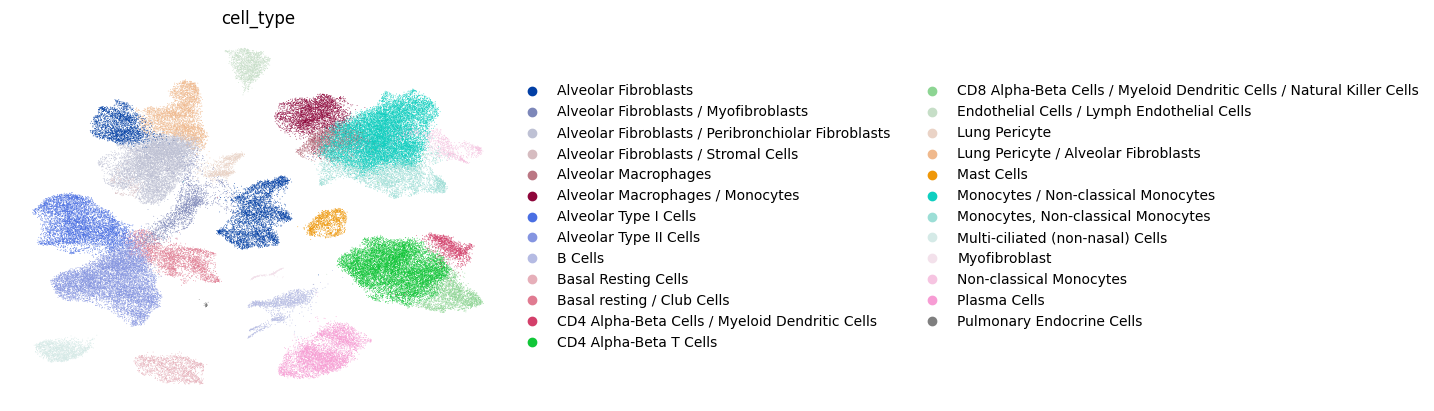

In [10]:
sc.pl.umap(adata_combined, color= ["cell_type"], frameon=False)